## Inverse Mapping with the Pounce Solver

Author: Victor Alves - Carnegie Mellon University

The inverse mapping in opyrability solves one nonlinear program (NLP) per point of the Desired Output Set (DOS) grid. As of this release the default solver is **[Pounce](https://kitchingroup.cheme.cmu.edu/pounce/)**, an interior-point NLP solver written in Rust by John Kitchin's group at Carnegie Mellon University. Its nonlinear core is a faithful port of the Ipopt filter line-search algorithm: the algorithm, the console log, and the option names follow Ipopt closely, so it drops in wherever ``method='ipopt'`` is used today.

Every interior-point iteration comes down to solving one linear system, the *KKT system*: a large, mostly empty (sparse) matrix that is symmetric and *indefinite* (it has both positive and negative eigenvalues). Ipopt hands this step to a Fortran linear-algebra library (for example the HSL solvers); Pounce instead uses **[FERAL](https://kitchingroup.cheme.cmu.edu/feral/)**, a sparse symmetric indefinite direct solver also written in Rust. "Direct" means it factorizes the matrix rather than iterating toward the solution, and it returns the *inertia* (the count of positive and negative eigenvalues), which the interior-point method uses to tell a genuine minimum from a saddle point and to decide when to regularize. Because FERAL is bundled, Pounce installs from precompiled wheels with ``pip install pounce-solver``, with no separate linear-algebra library to obtain and build. Ipopt through cyipopt remains available with ``method='ipopt'``.

This tutorial maps a small **continuous stirred-tank reactor (CSTR)** with consecutive reactions A $\rightarrow$ B $\rightarrow$ C {cite}`vinson00`, whose Achievable Output Set is nonconvex, and highlights:

-  The inverse mapping with ``method='pounce'`` (the default) and the one-argument switch to ``method='ipopt'``
-  Numerical derivatives, where Pounce computes central finite differences internally when ``ad=False``
-  JAX automatic differentiation with ``ad=True``, where opyrability supplies the exact objective gradient
-  A constrained inverse mapping

Let's define the process model and the operability sets. The reactor radius $R$ and the dimensionless inverse temperature $1/RT$ are the design inputs; the reactant and intermediate concentrations $C_A$ and $C_B$ are the outputs:

In [1]:
import time
import warnings
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# The default Pounce solver emits an informational warning when it falls back
# to finite-difference gradients (ad=False); silence it in this tutorial.
warnings.filterwarnings('ignore', message='pounce.minimize is approximating')


def CSTR(u):
    """
    Steady-state CSTR with the consecutive reactions A -> B -> C.

    Solves the steady-state mass balance for the reactant concentration (the
    meaningful root of the resulting quadratic) and evaluates the intermediate.

    Parameters
    ----------
    u : array-like, shape (2,)
        Inputs [R, RT]: the reactor radius R and the dimensionless inverse
        temperature 1/RT.

    Returns
    -------
    numpy.ndarray, shape (2,)
        Outputs [Ca, Cb]: the reactant and intermediate concentrations.
    """
    v0, Ca0, H = 1.0, 1.0, 1.0
    volume = np.pi * u[0] ** 2 * H
    k1, k2 = np.exp(-3.0 / u[1]), np.exp(-10.0 / u[1])
    a, b, c = volume * k1, v0 + volume * k2, -v0 * Ca0
    Ca = (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)
    Cb = k1 * Ca ** 2 * volume / v0
    return np.array([Ca, Cb])


def CSTR_jax(u):
    """
    JAX version of :func:`CSTR`, used for the ``ad=True`` path below.

    Identical model written with ``jax.numpy`` so opyrability can take the
    exact objective gradient with ``jax.grad``.

    Parameters
    ----------
    u : array-like, shape (2,)
        Inputs [R, RT]: reactor radius and dimensionless inverse temperature.

    Returns
    -------
    jax.numpy.ndarray, shape (2,)
        Outputs [Ca, Cb]: the reactant and intermediate concentrations.
    """
    v0, Ca0, H = 1.0, 1.0, 1.0
    volume = jnp.pi * u[0] ** 2 * H
    k1, k2 = jnp.exp(-3.0 / u[1]), jnp.exp(-10.0 / u[1])
    a, b, c = volume * k1, v0 + volume * k2, -v0 * Ca0
    Ca = (-b + jnp.sqrt(b ** 2 - 4 * a * c)) / (2 * a)
    Cb = k1 * Ca ** 2 * volume / v0
    return jnp.array([Ca, Cb])


AIS_bounds = np.array([[0.25, 3.00],
                       [1.00, 15.00]])
DOS_bounds = np.array([[0.15, 0.30],
                       [0.25, 0.40]])

u0 = np.array([1.5, 8.0])      # Initial estimate [R, RT].
lb = np.array([0.25, 1.0])
ub = np.array([3.00, 15.0])

labels = ['$R$', '$1/RT$', '$C_A$', '$C_B$']

### A nonconvex achievable output set

Mapping the input set forward shows the shape of this problem: as the inputs vary, the conversion of A falls while the intermediate B first rises and then falls, so the Achievable Output Set is nonconvex and bends back on itself.

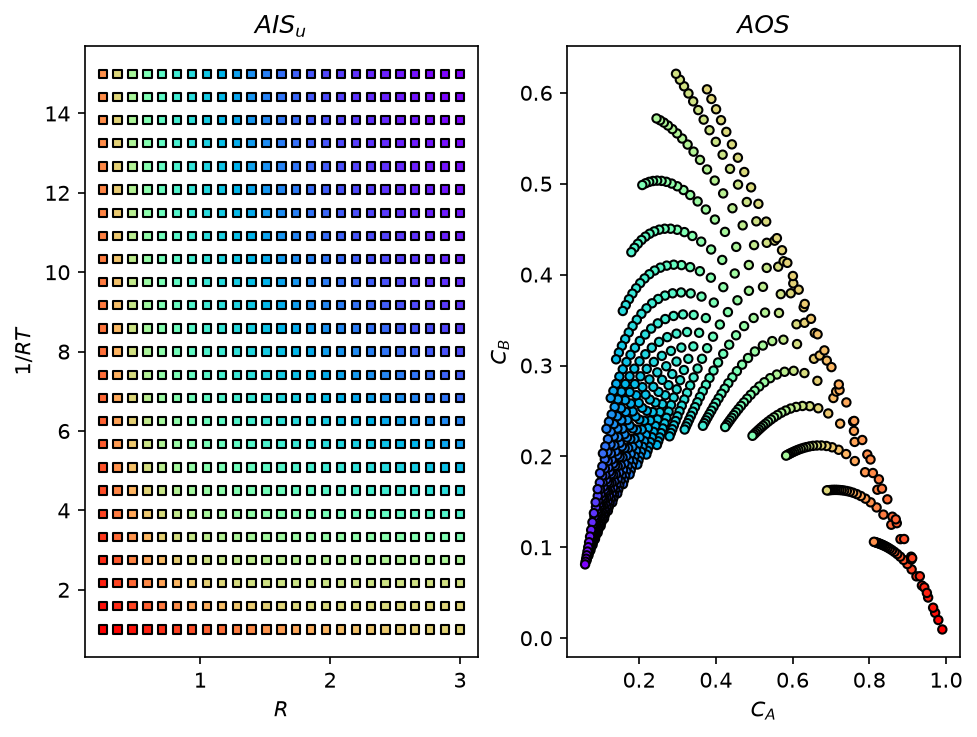

In [2]:
from opyrability import AIS2AOS_map

AIS, AOS = AIS2AOS_map(CSTR, AIS_bounds, [25, 25],
                       plot=True,
                       labels=labels)

### Inverse mapping with numerical derivatives (default)

With ``ad=False`` (the default), Pounce computes central finite differences internally, so any black-box model works. Solving the same inverse mapping with both solvers:

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/225 [00:00<?, ?it/s]

Pounce: 2.24 s | cyipopt: 10.83 s
Max difference, DIS*: 3.71e-06
Max difference, DOS*: 2.12e-07


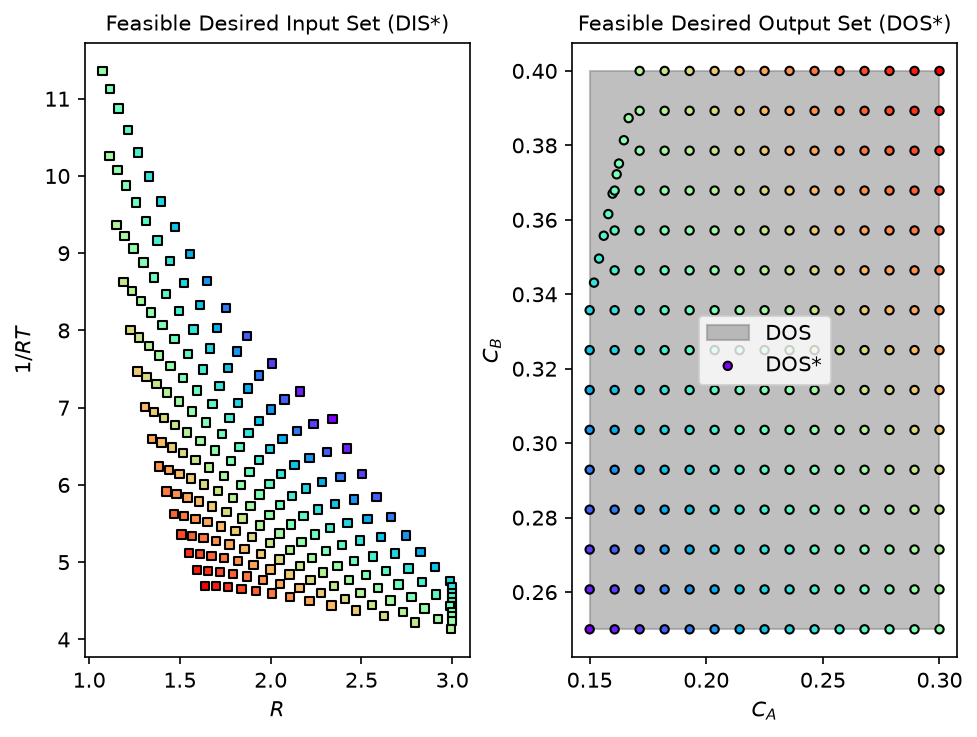

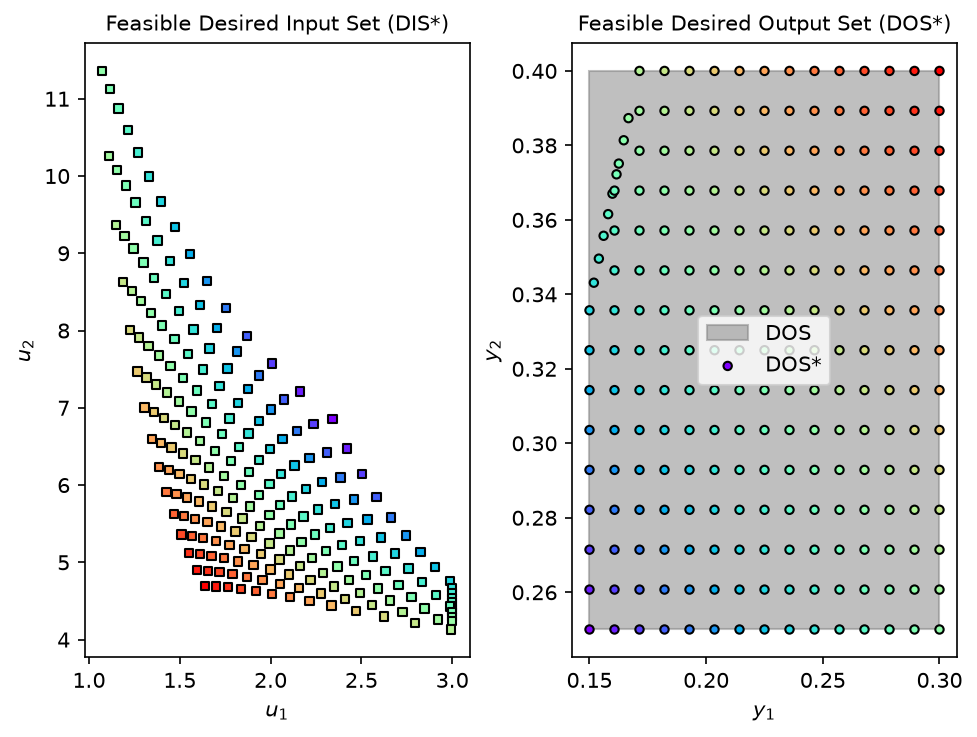

In [8]:
from opyrability import nlp_based_approach

# method='pounce' is the default; shown explicitly here for clarity.
start = time.time()
fDIS_pounce, fDOS_pounce, msg_pounce = nlp_based_approach(CSTR, 
                                                          DOS_bounds, 
                                                          [15, 15], 
                                                          u0, 
                                                          lb, 
                                                          ub,
                                                          method='pounce',
                                                          plot=True,
                                                          labels=labels)
t_pounce = time.time() - start

start = time.time()
fDIS_ipopt, fDOS_ipopt, msg_ipopt = nlp_based_approach(CSTR, 
                                                       DOS_bounds, 
                                                       [15, 15], 
                                                       u0, 
                                                       lb, 
                                                       ub,
                                                       method='ipopt',
                                                       plot=True)
t_ipopt = time.time() - start

print(f'Pounce: {t_pounce:.2f} s | cyipopt: {t_ipopt:.2f} s')
print(f'Max difference, DIS*: '
      f'{np.abs(np.asarray(fDIS_pounce) - np.asarray(fDIS_ipopt)).max():.2e}')
print(f'Max difference, DOS*: '
      f'{np.abs(np.asarray(fDOS_pounce) - np.asarray(fDOS_ipopt)).max():.2e}')

The two solvers find the same DIS*/DOS* to solver tolerance: Pounce is a faithful port of the Ipopt algorithm, so it can be swapped in anywhere ``method='ipopt'`` is used today.

### Automatic differentiation: exact gradients

With ``ad=True`` and a JAX-compatible model, opyrability builds the exact objective gradient with ``jax.grad``. The Hessian is left to Ipopt's limited-memory (L-BFGS) approximation, which both Pounce and cyipopt ($\geq$ 1.7.0) use when no Hessian is supplied and which is faster than a dense AD Hessian on problems of this size:

In [10]:
start = time.time()
fDIS_ad, fDOS_ad, msg_ad = nlp_based_approach(CSTR_jax,
                                              DOS_bounds, 
                                              [15, 15], 
                                              u0, 
                                              lb, 
                                              ub,
                                              method='pounce',
                                              ad=True,
                                              plot=False)
t_ad = time.time() - start

print(f'Pounce with exact JAX gradient: {t_ad:.2f} s')
print(f'Max difference vs numerical path, DOS*: '
      f'{np.abs(np.asarray(fDOS_ad) - np.asarray(fDOS_pounce)).max():.2e}')

 You have selected automatic differentiation as a method for obtaining higher-order data (Jacobians/Hessian),
 Make sure your process model is JAX-compatible implementation-wise.


  0%|          | 0/225 [00:00<?, ?it/s]

Pounce with exact JAX gradient: 113.10 s
Max difference vs numerical path, DOS*: 1.66e-11


### Constrained inverse mapping

Pounce consumes the same constraint dictionary format as cyipopt. Here a fabrication limit requires the inverse temperature to be at least twice the reactor radius, $1/RT \geq 2R$:

In [11]:
con = {'type': 'ineq', 'fun': lambda u: u[1] - 2.0 * u[0]}  # RT >= 2R

fDIS_con, fDOS_con, msg_con = nlp_based_approach(CSTR, 
                                                 DOS_bounds,
                                                 [15, 15], 
                                                 u0, 
                                                 lb, 
                                                 ub,
                                                 method='pounce',
                                                 constr=con,
                                                 plot=False)

violation = (2.0 * fDIS_con[:, 0] - fDIS_con[:, 1]).max()
print(f'Largest constraint violation (2R - RT): {violation:.2e}')

  0%|          | 0/225 [00:00<?, ?it/s]

Largest constraint violation (2R - RT): -4.65e-08


### Conclusions

**Key Results:**

- ``method='pounce'`` is the default inverse-mapping solver and reproduces the cyipopt result to solver tolerance on the curved CSTR, with numerical derivatives, with JAX gradients, and with constraints.
- Pounce installs from precompiled wheels with a single pip command, since it bundles the FERAL linear solver and needs no separate Fortran linear-algebra library.
- ``method='ipopt'`` remains available for users with cyipopt installed.

**Workflow Summary:**

1. ``pip install pounce-solver`` (already a core dependency of opyrability).
2. Call ``nlp_based_approach`` as usual; ``method='pounce'`` is the default.
3. Optionally set ``ad=True`` with a JAX-compatible model for exact objective gradients.